In [1]:
# Imports
# Importo las Bibliotecas que voy a usar en el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Functions
# Definición de las funciones quevoy a usar en el proyecto.

def calcular_porcentaje_nulos(grupo):
    '''
    Devuelve el porcentaje de valores nulos en un grupo
    
    grupo: es la serie de pandas (una columna filtrada por un valor específico)
    grupo.isnull().sum(): cuántos valores nulos hay en el grupo
    len(grupo): cantidad total de registros en ese grupo
    '''
    return (grupo.isnull().sum() / len(grupo)) * 100

In [3]:
# DataSources
# Cargo la fuente de datos con la que voy a trabajar en el proyecto
df = pd.read_csv("data/ncr_ride_bookings.csv")

# Inspección inicial de datos
Luego de haber cargado el dataset, hago una inspección geneal del dataframe buscando validar que sea útil para el TP

## Inspección rápida

In [4]:
# El DataFrame tiene que tener al menos 50K registros y 10 columnaspara este TP.
df.shape

(150000, 21)

In [5]:
# veo la estructura del DataFrame.
# con el datatype puedo completar el diccionario de datos que pide el TP
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [6]:
df.head() # Sin argumentos, el método head() me trae los primeros 5 elementos del DataFrame

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [7]:
# Obtengo una muestra al azar del DataFrame
df.sample()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
127513,2024-06-10,11:45:06,"""CNR3650103""",Completed,"""CID9374462""",Go Mini,Okhla,Rajouri Garden,10.4,22.3,...,NaN,NaN,NaN,NaN,NaN,104.0,18.53,4.2,4.6,UPI


In [8]:
df.tail() # Sin argumentos, el método tail() me trae los últimos 5 elementos del DataFrame

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI
149999,2024-03-10,15:38:03,"""CNR3447390""",Completed,"""CID4108667""",Premier Sedan,Ashok Park Main,Gurgaon Sector 29,3.5,33.7,...,NaN,NaN,NaN,NaN,NaN,806.0,21.19,4.6,4.9,Credit Card


In [9]:
# Uso 'describe' par ver si, a simple vista, hay algún valor que me llame la atención
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [10]:
# hay elementos duplicados?
res = df.duplicated().sum()
print (f"Hay {res} elementos duplicados")

Hay 0 elementos duplicados


In [11]:
# recuento de valores únicos que tiene cada columna
df.nunique()

Date                                    365
Time                                  62910
Booking ID                           148767
Booking Status                            5
Customer ID                          148788
Vehicle Type                              7
Pickup Location                         176
Drop Location                           176
Avg VTAT                                181
Avg CTAT                                351
Cancelled Rides by Customer               1
Reason for cancelling by Customer         5
Cancelled Rides by Driver                 1
Driver Cancellation Reason                4
Incomplete Rides                          1
Incomplete Rides Reason                   3
Booking Value                          2566
Ride Distance                          4901
Driver Ratings                           21
Customer Rating                          21
Payment Method                            5
dtype: int64

## Análisis de columnas y valores

### Columnas de tipo fecha
'Date' y 'Time' están como String, las convierto a fecha para poder trabajarlas luego

In [12]:
# Timestamp: creo una columna tipo TimeStamp que contenga a las columnas anteriores
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

In [13]:
# Fecha
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
# Hora
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')

In [15]:
df['Date'].describe()

count                        150000
mean     2024-06-30 16:42:40.320000
min             2024-01-01 00:00:00
25%             2024-03-31 00:00:00
50%             2024-07-01 00:00:00
75%             2024-09-30 00:00:00
max             2024-12-30 00:00:00
Name: Date, dtype: object

In [16]:
df['Time'].describe()

count                        150000
mean     1900-01-01 14:32:00.931034
min             1900-01-01 00:00:00
25%             1900-01-01 10:20:25
50%             1900-01-01 15:23:33
75%             1900-01-01 18:57:31
max             1900-01-01 23:59:59
Name: Time, dtype: object

In [17]:
df['Timestamp'].describe()

count                        150000
mean     2024-07-01 07:14:41.251033
min             2024-01-01 00:19:34
25%      2024-03-31 22:55:36.250000
50%      2024-07-01 09:24:52.500000
75%      2024-09-30 13:46:07.250000
max             2024-12-30 23:36:11
Name: Timestamp, dtype: object

### Campos float
```
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by Customer        10500 non-null   float64       
 12  Cancelled Rides by Driver          27000 non-null   float64       
 14  Incomplete Rides                   9000 non-null    float64       
 16  Booking Value                      102000 non-null  float64       
 17  Ride Distance                      102000 non-null  float64       
 18  Driver Ratings                     93000 non-null   float64       
 19  Customer Rating                    93000 non-null   float64       
 ```

In [18]:
df['Avg VTAT'].describe()

count    139500.000000
mean          8.456352
std           3.773564
min           2.000000
25%           5.300000
50%           8.300000
75%          11.300000
max          20.000000
Name: Avg VTAT, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

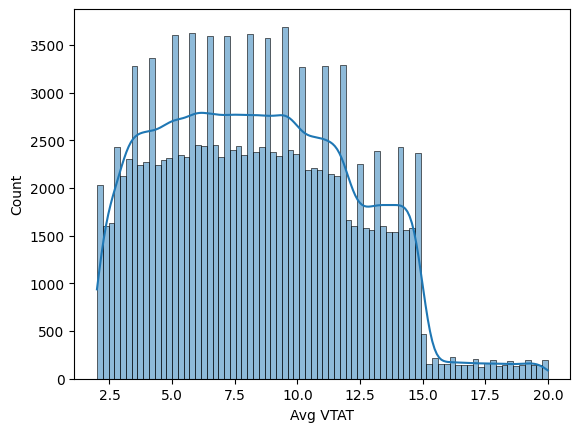

In [19]:
sns.histplot(df['Avg VTAT'], kde=True)
plt.show

In [20]:
df['Avg CTAT'].describe()

count    102000.000000
mean         29.149636
std           8.902577
min          10.000000
25%          21.600000
50%          28.800000
75%          36.800000
max          45.000000
Name: Avg CTAT, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

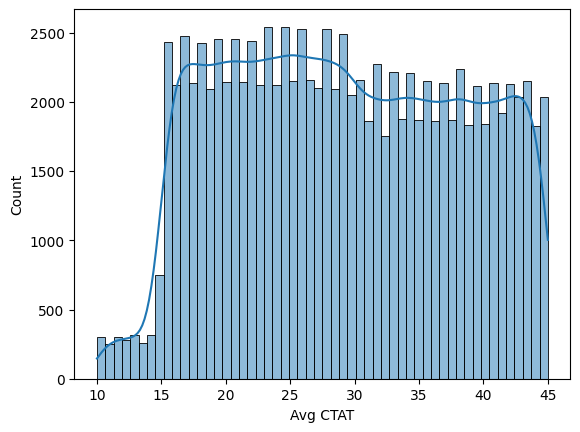

In [21]:
sns.histplot(df['Avg CTAT'], kde=True)
plt.show

In [22]:
df['Booking Value'].describe()

count    102000.000000
mean        508.295912
std         395.805774
min          50.000000
25%         234.000000
50%         414.000000
75%         689.000000
max        4277.000000
Name: Booking Value, dtype: float64

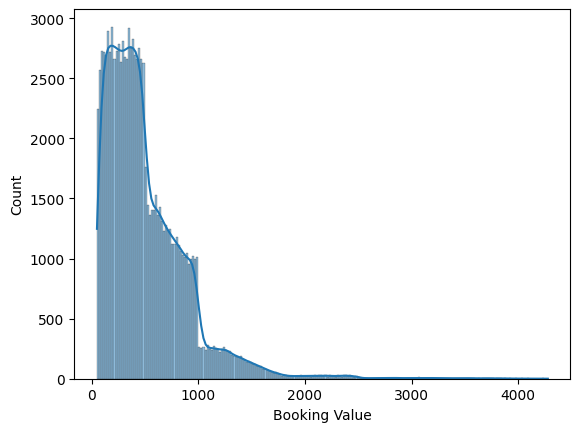

In [23]:
sns.histplot(df['Booking Value'], kde=True)
plt.show()

In [24]:
df['Ride Distance'].describe()

count    102000.000000
mean         24.637012
std          14.002138
min           1.000000
25%          12.460000
50%          23.720000
75%          36.820000
max          50.000000
Name: Ride Distance, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

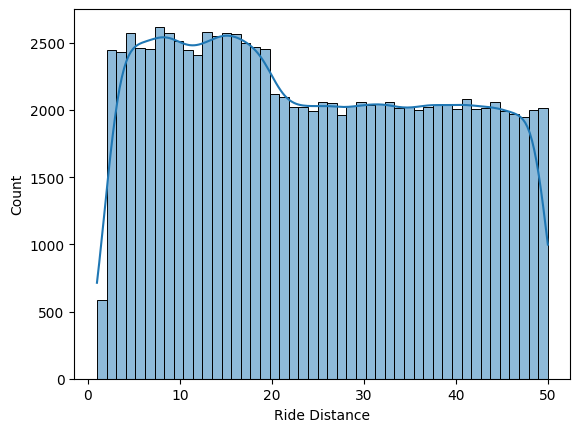

In [25]:
sns.histplot(df['Ride Distance'], kde=True)
plt.show

In [26]:
# Datos de distancia de viaje bastente parejos, más concentración entre ~3 y ~20

#### Analizo el posible uso de dtype Float para marcas tipo Boolean
Veo que hay varios float y quiero validar mi hipótesis de que funcionan como boolean

In [27]:
# 'Cancelled Rides by Customer'
df['Cancelled Rides by Customer'].unique()

array([nan,  1.])

In [28]:
# Cómo se distribuyen los valores?
df['Cancelled Rides by Customer'].describe()

count    10500.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: Cancelled Rides by Customer, dtype: float64

In [29]:
# Parece que es un boolean... traigo los datos de los registros que no tienen 'Cancelled RIsdes by Customre' como NaN
filtro = df[df['Cancelled Rides by Customer'].notna()]
filtro[['Booking ID', 'Customer ID', 'Booking Status', 'Cancelled Rides by Customer','Reason for cancelling by Customer']]

,Booking ID,Customer ID,Booking Status,Cancelled Rides by Customer,Reason for cancelling by Customer
18,"""CNR6126048""","""CID1060329""",Cancelled by Customer,1.0,Driver is not moving towards pickup location
39,"""CNR4218487""","""CID3037053""",Cancelled by Customer,1.0,Driver is not moving towards pickup location
46,"""CNR4862806""","""CID7875150""",Cancelled by Customer,1.0,Driver asked to cancel
62,"""CNR2497989""","""CID5007066""",Cancelled by Customer,1.0,Driver is not moving towards pickup location
78,"""CNR2601752""","""CID9283370""",Cancelled by Customer,1.0,Driver asked to cancel
...,...,...,...,...,...
149943,"""CNR3486851""","""CID7572575""",Cancelled by Customer,1.0,Wrong Address
149952,"""CNR8257559""","""CID1017725""",Cancelled by Customer,1.0,Driver asked to cancel
149956,"""CNR6030764""","""CID6873715""",Cancelled by Customer,1.0,Driver is not moving towards pickup location
149963,"""CNR4272547""","""CID2998831""",Cancelled by Customer,1.0,Driver is not moving towards pickup location


In [30]:
filtro[['Cancelled Rides by Customer']].describe()

,Cancelled Rides by Customer
count,10500.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [31]:
# Conclusión: 
# min, max y mean = 1
# std = 0
#
# entonces
#
# 'Cancelled Rides by Customer' actía como boolean:
#    Si es 1, el cliente canceló
#    Si es NaN, el cliente no canceló

In [32]:
# 'Cancelled Rides by Driver' puede pasar lo mismo que con 'Cancelled Rides by Customer'.
# Uso lo que hice antes con la otra columna
print (f"Valores unicos: {df['Cancelled Rides by Driver'].unique()}\n")
filtro = df[df['Cancelled Rides by Driver'].notna()]
filtro[['Cancelled Rides by Driver']].describe()

Valores unicos: [nan  1.]



,Cancelled Rides by Driver
count,27000.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [33]:
# Conclusión
# con esta variable paas lo mismo que con 'Cancelled Rides by Customer', actía como boolean:
#    Si es 1, el conductor canceló
#    Si es NaN, el conductor no canceló

In [34]:
# 'Incomplete Rides' puede pasar lo mismo que con 'Cancelled Rides by Customer'.
# Uso lo que hice antes con la otra variable
print (f"Valores unicos: {df['Incomplete Rides'].unique()}\n")
filtro = df[df['Incomplete Rides'].notna()]
filtro[['Incomplete Rides']].describe()

Valores unicos: [nan  1.]



,Incomplete Rides
count,9000.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [35]:
# Conclusión
# con esta variable paas lo mismo que con 'Cancelled Rides by Customer', actía como boolean:
#    Si es 1, el viaje se interrumpió
#    Si es NaN, si el viaje se completó

#### Conclusión sobre estos valores float como boolean
Las columnas:
> Cancelled Rides by Customer<br>
> Cancelled Rides by Driver<br>
> Incomplete Rides

Son usadas como marcas de tipo 'bool' aunque estén guardadas como float.

Los Nulos no represenan falta de datos sino un valor 'falso'.
Estas variables se tratarán como si fueran ```Bool``` en este análisis.

### Columnas tipo string

In [56]:
# Hay alguons campos de 'Razones', son categóricas?
# 'Reason for cancelling by Customer'
# 'Driver Cancellation Reason'
# 'Incomplete Rides Reason'

# hay un método para contar los valores e incluir los NaN (dropna=False). Lo uso para no perder de vista nada
keys=['Reason for cancelling by Customer', 'Driver Cancellation Reason','Incomplete Rides Reason'] # Estas sonlas columnas que quiero analizar
for col in df[keys]:
    print (f"{df[col].value_counts(dropna=False)}\n")
    

Reason for cancelling by Customer
NaN                                             139500
Wrong Address                                     2362
Change of plans                                   2353
Driver is not moving towards pickup location      2335
Driver asked to cancel                            2295
AC is not working                                 1155
Name: count, dtype: int64

Driver Cancellation Reason
NaN                                    123000
Customer related issue                   6837
The customer was coughing/sick           6751
Personal & Car related issues            6726
More than permitted people in there      6686
Name: count, dtype: int64

Incomplete Rides Reason
NaN                  141000
Customer Demand        3040
Vehicle Breakdown      3012
Other Issue            2948
Name: count, dtype: int64



In [57]:
# Conclusión
# 'Reason for cancelling by Customer', 'Driver Cancellation Reason', 'Incomplete Rides Reason'
# son categóricas nominales, puede que sean las opciones que da la app a la hora de cancelar o interrumpir el viarje.

In [44]:
# Qué pasa con los ratings?
# 'Driver Ratings', 'Customer Rating'
keys=['Driver Ratings', 'Customer Rating']
for col in df[keys]:
    #print (f"{df[col].value_counts(dropna=False)}\n")
    print(f"{col}\n{df[col].unique()}")

Driver Ratings
[nan 4.9 4.6 4.1 4.  4.4 4.2 4.7 3.8 5.  3.7 3.1 4.5 3.9 4.3 3.3 3.2 4.8
 3.6 3.5 3.4 3. ]
Customer Rating
[nan 4.9 5.  4.3 4.6 4.1 4.2 4.7 4.4 3.6 4.5 3.3 3.8 3.7 4.8 3.9 3.4 3.2
 3.1 4.  3.  3.5]


In [68]:
# Conclusión ratings >> son variables categóricas nominales

In [67]:
# Qué pasa con 'Booking Status'?
df['Booking Status'].unique().tolist()

['No Driver Found',
 'Incomplete',
 'Completed',
 'Cancelled by Driver',
 'Cancelled by Customer']

In [69]:
# 'Booking Status' es una lista de cómo terminó el viaje:
# Completed es el único valor positivo, el resto indica que el viaje no se realizó o no se completó

# Esto me puede servir para analizar más adelante> 

## Valores nulos NaN
Con los datos nulos sucede algo curioso: hay demasiados y con números muy parejos entre sí (es como que vienen de a dos, o que si una columna tiene null, hay otr aque también es null)

In [46]:
# Campos nulos (NaN)
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
Timestamp                                 0
dtype: int64

In [66]:
# Por qué hay tantos valores nulos?
# Por qué la cantidad de valores nulos es redonda?


# cuenta cuántos valores nulos (NaN) tiene cada columna del DataFrame
datos_faltantes = df.isnull().sum() 
# convierte los conteos de nulos en porcentajes
porcentaje_faltantes = (datos_faltantes / len(df)) * 100 

# armo un resumen con los datos nulos a ver si obtengo algo más de info
resumen = pd.DataFrame({
    'Columna': df.columns,
    'Cantidad_Faltante': datos_faltantes.values,
    'No_Nulos': df.notnull().sum(),
    'Porcentaje_Faltante': porcentaje_faltantes.values
})

# armo un filtro para obtener sólo aquellas coluymnas en que 'Porcentaje_Faltante' no es 0
filtro = resumen['Porcentaje_Faltante'] != 0
resumen[filtro]

,Columna,Cantidad_Faltante,No_Nulos,Porcentaje_Faltante
Avg VTAT,Avg VTAT,10500,139500,7.0
Avg CTAT,Avg CTAT,48000,102000,32.0
Cancelled Rides by Customer,Cancelled Rides by Customer,139500,10500,93.0
Reason for cancelling by Customer,Reason for cancelling by Customer,139500,10500,93.0
Cancelled Rides by Driver,Cancelled Rides by Driver,123000,27000,82.0
Driver Cancellation Reason,Driver Cancellation Reason,123000,27000,82.0
Incomplete Rides,Incomplete Rides,141000,9000,94.0
Incomplete Rides Reason,Incomplete Rides Reason,141000,9000,94.0
Booking Value,Booking Value,48000,102000,32.0
Ride Distance,Ride Distance,48000,102000,32.0


Acá se puede ver bien que hay columnas cuya relación de valores nulos es idéntica:
```
Cancelled Rides by Customer 		139500 	10500 	93.0
Reason for cancelling by Customer 	139500 	10500 	93.0

Cancelled Rides by Driver 		123000 	27000 	82.0
Driver Cancellation Reason 		123000 	27000 	82.0

Incomplete Rides 			141000 	9000 	94.0
Incomplete Rides Reason 		141000 	9000 	94.0

Booking Value 				48000 	102000 	32.0
Ride Distance 				48000 	102000 	32.0

Driver Ratings 				57000 	93000 	38.0
Customer Rating 			57000 	93000 	38.0

> 'Payment Method' tiene los mismos valores nulos que 'Booking Value' y 'Ride Distance'
> Hipótesis: cuando hay valroes NaN en 'Booking Value' y 'Ride Distance', 'Payment Method' también será nulo porque el viaje no s realizó

Payment Method 	 			48000 	102000 	32.0
```

In [124]:
# Que pasa con las columnas que no tienen datos (NaN), según el tip ode "Booking Stauts"? 
# --> Quiero saber si ciertos estados de viaje tienen más datos faltantes que otros.

#key_columns = ['Booking Value','Avg VTAT', 'Avg CTAT','Cancelled Rides by Customer','Reason for cancelling by Customer','Cancelled Rides by Driver',
# 'Driver Cancellation Reason','Incomplete Rides','Incomplete Rides Reason','Ride Distance','Driver Ratings','Customer Rating','Payment Method']

# Pongo menos columnas, porque hay algunas que están relacionadas entre sí, como 'Cancelled Rides by Customer' y 'Reason for cancelling by Customer'"
#key_columns = ['Booking Value','Avg VTAT', 'Avg CTAT','Cancelled Rides by Customer','Cancelled Rides by Driver','Incomplete Rides','Ride Distance','Driver Ratings','Customer Rating','Payment Method']
key_columns = ['Booking Value','Cancelled Rides by Customer','Cancelled Rides by Driver','Incomplete Rides','Ride Distance','Driver Ratings','Customer Rating','Payment Method']

# Crear un DataFrame con todos los resultados
resultados = {}

# Para cada columna, obtengo el recuento de valores nulos según valor que adopte 'Booking Status'
for col in key_columns:
    if col in df.columns:
        nan_por_estado = df.groupby('Booking Status')[col].apply(calcular_porcentaje_nulos)
        resultados[col] = nan_por_estado


# Recorro cada columna definida previamente en `key_columns`
for col in key_columns:
    if col in df.columns:
        # Agrupo los datos según el estado de la reserva (`Booking Status`) y calculo el porcentaje de valores nulos de la columna actual
        # para esto uso la función `calcular_porcentaje_nulos` que definí al principio del código
        nan_por_estado = df.groupby('Booking Status')[col].apply(calcular_porcentaje_nulos)
        
        # Guardo el resultado en el diccionario `resultados`
        #   - la clave es el nombre de la columna analizada
        #   - el valor es una Serie con el porcentaje de NaN por estado de reserva
        resultados[col] = nan_por_estado
        
df_resultados = pd.DataFrame(resultados).T # Traspongo el DataFrame para visualizarlo mejor
df_resultados

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Booking Value,100.0,100.0,0.0,0.0,100.0
Cancelled Rides by Customer,0.0,100.0,100.0,100.0,100.0
Cancelled Rides by Driver,100.0,0.0,100.0,100.0,100.0
Incomplete Rides,100.0,100.0,100.0,0.0,100.0
Ride Distance,100.0,100.0,0.0,0.0,100.0
Driver Ratings,100.0,100.0,0.0,100.0,100.0
Customer Rating,100.0,100.0,0.0,100.0,100.0
Payment Method,100.0,100.0,0.0,0.0,100.0


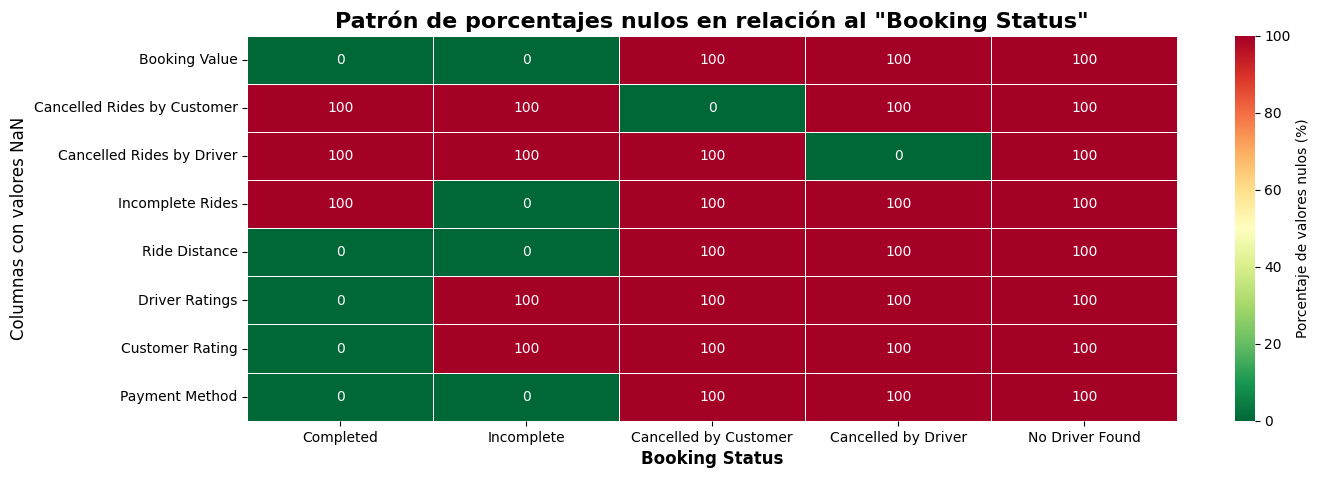

In [128]:
# Puedo mostrar alguna correspondencia usando algún gráfico? (La IA me sugiere barras ,dispersión o mapa de calor. Voy con mapa de calor)

# Reordenar columnas para mejorar la visualización
#   Después de algunas iteraciones, este orden muestra mejora la información, se ve bien cómo faltan cada vez más datos si el viaje resultó
#   incompleto, cancelado o si no hubo un conductor disponible.
orden_status = ['Completed', 'Incomplete', 'Cancelled by Customer', 'Cancelled by Driver',  'No Driver Found']

df_heatmap = df_resultados[orden_status] 

# Crear el heatmap. Requiere algo de trabajo para que se vea más o menos bien.
plt.figure(figsize=(15, 5)) 
sns.heatmap(df_heatmap, 
            annot=True,  # True: Muestra los valores | False: Esconde los valores
            fmt='.0f',   # Valores sin decimales
            cmap='RdYlGn_r',  # Rojo = muchos nulos, Verde = pocos nulos
            cbar_kws={'label': 'Porcentaje de valores nulos (%)'},
            linewidths=0.5, # le pongo un poco de separación entre celdas para que se vea mejor
           )

plt.title('Patrón de porcentajes nulos en relación al "Booking Status"', fontsize=16, fontweight='bold')
plt.xlabel('Booking Status', fontsize=12, fontweight='bold')
plt.ylabel('Columnas con valores NaN', fontsize=12)
plt.xticks(rotation=0, ha='center')

plt.show()

In [ ]:
# Con este mapa de calor se observa claramente quela columna 'Completed' es la que tiene menos cantidad de valores nulos

# Conclusiones sobre los datos
**Sobre los datos nulos (NaN):**

Hay una relación directa entre los datos nulos y el estado de la reserva:
- ```Completed```: Están todos los datos necesarios.
- ```Cancelled by Customer```/```Cancelled by Driver```: tienen información parcial, porque el viaje no se realizó.
- ```Incomplete```: tiene algo de data, pero no es el viaje entero
- ```No driver Found```: no tiene data del viaje

**Conclusiones**
- Los datos que faltan (NaN) obedecen a un tema de diseño, no a un problema de carga, o datos faltantes.
- Los datos que faltan (NaN) en estas columnas son información en sí mismos.

# Hipótesis
Con el dataset analizado, se proponenpuedo intentar abordar estas preguntas:
- ¿Cómo varía la demanda de viajes según el horario del día?
- ¿Existen horarios en los que se concentran más solicitudes de viajes?
- ¿Qué diferencias pueden observarse entre los patrones de demanda de días hábiles y fines de semana?
- ¿Existen zonas con una mayor concentración de solicitudes de viaje?
- ¿Cómo se comportan los distintos tipos de vehículos en términos de ingresos generados?
- ¿Qué tipos de vehículos presentan mayores tasas de cancelación?
- ¿Existen diferencias en los tiempos de espera según el tipo de vehículo solicitado?
- ¿Cómo se distribuyen los montos facturados por viaje?
- ¿Qué relación existe entre la distancia recorrida y el valor del viaje?
- ¿Existen franjas horarias con mayor facturación total?
- ¿Cómo varían las cancelaciones según el horario y el nivel de demanda?
- ¿Cuáles son las razones de cancelación más frecuentes registradas en el dataset?
- ¿Qué tipos de vehículos presentan mayores cancelaciones por parte de los conductores?
- ¿Qué relación existe entre el tiempo de espera y la calificación otorgada por los clientes?
- ¿Cómo impactan las cancelaciones o incidencias en las valoraciones de los usuarios?
- ¿Existen diferencias en las calificaciones promedio según el tipo de vehículo utilizado?



## ¿Cómo varía la demanda de viajes según el horario del día?

In [151]:
df['Hour'] = pd.to_datetime(df['Time']).dt.hour # Creo una columna para la hora, la necesito para responder esta pregunta
viajes_por_hora = df['Hour'].value_counts()

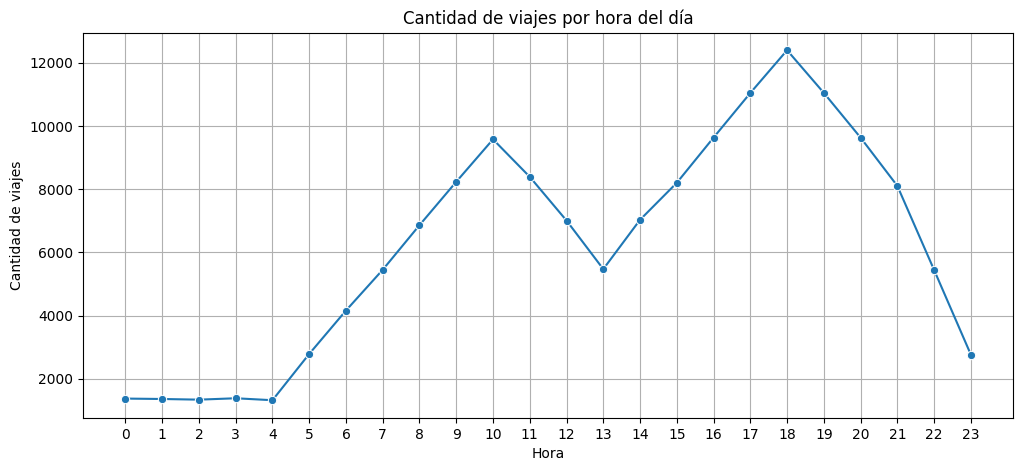

In [153]:
# gráfico de línea
plt.figure(figsize=(12,5))

sns.lineplot(
    x=viajes_por_hora.index,
    y=viajes_por_hora.values,
    marker='o'
)

plt.title('Cantidad de viajes por hora del día')
plt.xlabel('Hora')
plt.ylabel('Cantidad de viajes')

plt.xticks(range(0,24))
plt.grid(True)

plt.show()

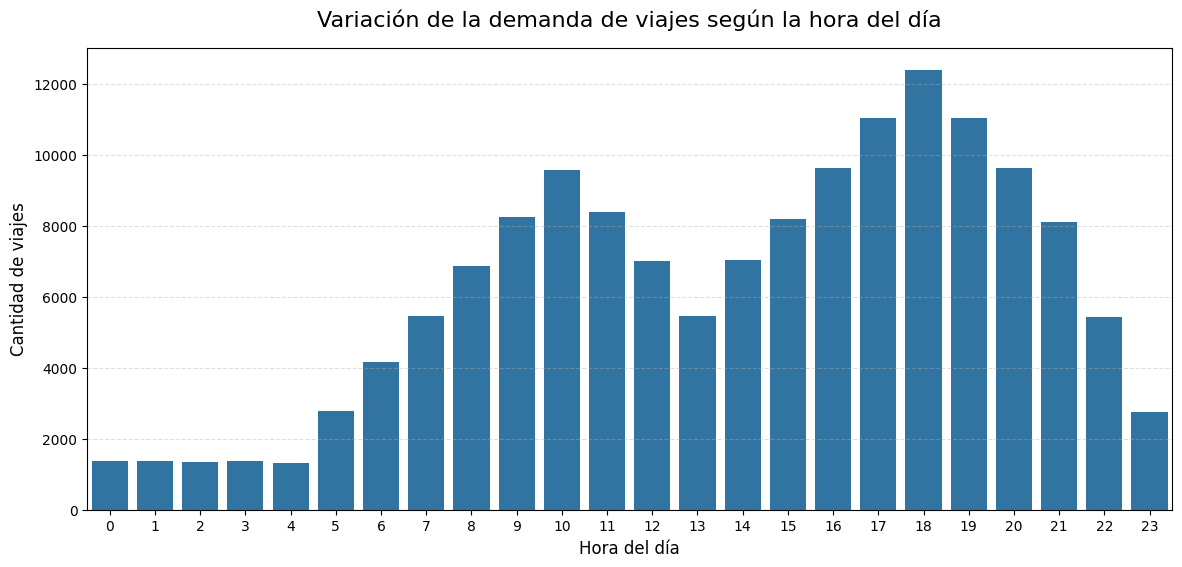

In [163]:
# Contamos cantidad de viajes por hora
viajes_por_hora = (
    df['Hour']
    .value_counts()
    .sort_index()
)

# Configuración del gráfico
plt.figure(figsize=(14,6))
sns.barplot(
    x=viajes_por_hora.index,
    y=viajes_por_hora.values
)

# Títulos y etiquetas
plt.title('Variación de la demanda de viajes según la hora del día', fontsize=16, pad=15)
plt.xlabel('Hora del día',fontsize=12)
plt.ylabel('Cantidad de viajes', fontsize=12)
plt.xticks(range(0,24)) # Mostrar todas las horas en el eje X
plt.grid(axis='y', linestyle='--', alpha=0.4) # agrego grilla horizontal para facilitar lectura, el valor de alpha me permite hacerla semi-transparente
#plt.tight_layout() # Ajuste automático de márgenes

plt.show()

In [52]:
#df['Booking Status'].unique().tolist()
#cols = df.columns
key_columns = ['Booking Status', 'Vehicle Type', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 
'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Driver Ratings', 'Customer Rating', 'Payment Method']

for col in df[key_columns]:
    u = df[col].unique().tolist()
    print (f"Valores únicos de {col}: {u}")



Valores únicos de Booking Status: ['No Driver Found', 'Incomplete', 'Completed', 'Cancelled by Driver', 'Cancelled by Customer']
Valores únicos de Vehicle Type: ['eBike', 'Go Sedan', 'Auto', 'Premier Sedan', 'Bike', 'Go Mini', 'Uber XL']
Valores únicos de Cancelled Rides by Customer: [nan, 1.0]
Valores únicos de Reason for cancelling by Customer: [nan, 'Driver is not moving towards pickup location', 'Driver asked to cancel', 'AC is not working', 'Change of plans', 'Wrong Address']
Valores únicos de Cancelled Rides by Driver: [nan, 1.0]
Valores únicos de Driver Cancellation Reason: [nan, 'Personal & Car related issues', 'Customer related issue', 'More than permitted people in there', 'The customer was coughing/sick']
Valores únicos de Incomplete Rides: [nan, 1.0]
Valores únicos de Incomplete Rides Reason: [nan, 'Vehicle Breakdown', 'Other Issue', 'Customer Demand']
Valores únicos de Driver Ratings: [nan, 4.9, 4.6, 4.1, 4.0, 4.4, 4.2, 4.7, 3.8, 5.0, 3.7, 3.1, 4.5, 3.9, 4.3, 3.3, 3.2, 4.8